# Structural Exclusion and Hypertransmission Segmentation

This notebook investigates an alternative approach to hypertransmission and
barcoding detection.

Rather than immediately combining several standardized features into a weighted
score, the workflow separates structural information from intensity information.

The experimental sequence is:

1. Load and preprocess a selected OCT B-scan.
2. Calculate simple gradient-based verticality.
3. Construct a structural-pixel exclusion mask.
4. Estimate the intensity distribution of the remaining choroidal pixels.
5. Calculate column-level mean, median, and upper-quantile intensity.
6. Construct and visualize candidate hypertransmission regions.
7. Refine candidate regions using depth continuity and vertical organization.

The purpose of this notebook is diagnostic. Thresholds and segmentation rules
are exploratory and are not yet clinically validated.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError(
            "Could not locate the project root."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.detector.data import build_grouped_volume_registry, load_e2e_volume
from src.detector.preprocessing import preprocess_bscan
from src.detector.features import compute_column_intensity_statistics, compute_simple_verticality_map, create_structural_mask
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\u0667281\Desktop\JMA\barcoding-amd


## Volume and B-Scan Selection

A single volume and explicit zero-based B-scan index are selected for the first
diagnostic experiment.

The same notebook can later be rerun on other subjects and scans by changing
only `SUBJECT_ID` and `BSCAN_INDEX`.

In [2]:
E2E_DIRECTORY = PROJECT_ROOT / "data"  / "heyex" / "meta"

PROGRESSION_GROUPS = {
    "fast": [8,9,12,41,49],
    "slow": [17,23,35,36,47],
}

registry = build_grouped_volume_registry(
    e2e_directory=E2E_DIRECTORY,
    progression_groups=PROGRESSION_GROUPS,
)

print( "Registry entries:",len(registry))

Registry entries: 10


In [3]:
SUBJECT_ID, BSCAN_INDEX = 8, 48

In [4]:
matching_records = [
    record
    for record in registry
    if int(record.subject_id) == int(SUBJECT_ID)
]

if not matching_records:
    raise KeyError( f"Subject {SUBJECT_ID} was not found in the volume registry.")

volume_record = matching_records[0]
volume = load_e2e_volume(volume_record.e2e_path)

if not ( 0 <= BSCAN_INDEX< len(volume)):
    raise IndexError(
        f"BSCAN_INDEX={BSCAN_INDEX} is outside "
        f"the valid range 0 to {len(volume) - 1}."
    )

print("Subject:", volume_record.subject_id)
print("Progression group:",volume_record.progression_group,)
print("Number of B-scans:",len(volume),)
print("Selected B-scan:",BSCAN_INDEX,)
print("Volume shape:",volume.shape,)

Subject: 8
Progression group: fast
Number of B-scans: 97
Selected B-scan: 48
Volume shape: (97, 496, 512)


## Preprocessing

The selected B-scan is:

1. flattened to Bruch's membrane;
2. cropped to a 150-pixel region below BM;
3. normalized using whole-ROI z-score normalization;
4. denoised using an anisotropic Gaussian filter.

The Gaussian standard deviations are 1.0 pixels through depth and 0.5 pixels
horizontally. This reduces speckle while limiting horizontal blurring of narrow
vertical structures.

In [5]:
PREPROCESSING_CONFIG = {
    "layer_name": "BM",

    # Flattening
    "reference_row": None,
    "flatten_fill_value": 0.0,

    # Sub-layer crop
    "depth_below_layer": 150,
    "include_boundary": True,
    "require_full_depth": False,
    "crop_fill_value": 0.0,

    # Whole-ROI normalization
    "normalization_method": "zscore",
    "lower_percentile": 1.0,
    "upper_percentile": 99.0,

    # Anisotropic Gaussian denoising
    "denoise_method": "gaussian",
    "gaussian_sigma": (
        1.0, # z
        0.5, # x
    ),
}

In [6]:
processed = preprocess_bscan(
    volume=volume,
    bscan_index=BSCAN_INDEX,
    **PREPROCESSING_CONFIG,
)

print("Raw shape:",processed.raw_bscan.shape)
print("Flattened shape:",processed.flattened_bscan.shape)
print("Sub-layer crop shape:",processed.sub_layer_crop.shape)
print("Normalized shape:",processed.normalized_scan.shape)
print("Denoised shape:",processed.denoised_scan.shape)

Raw shape: (496, 512)
Flattened shape: (496, 512)
Sub-layer crop shape: (150, 512)
Normalized shape: (150, 512)
Denoised shape: (150, 512)


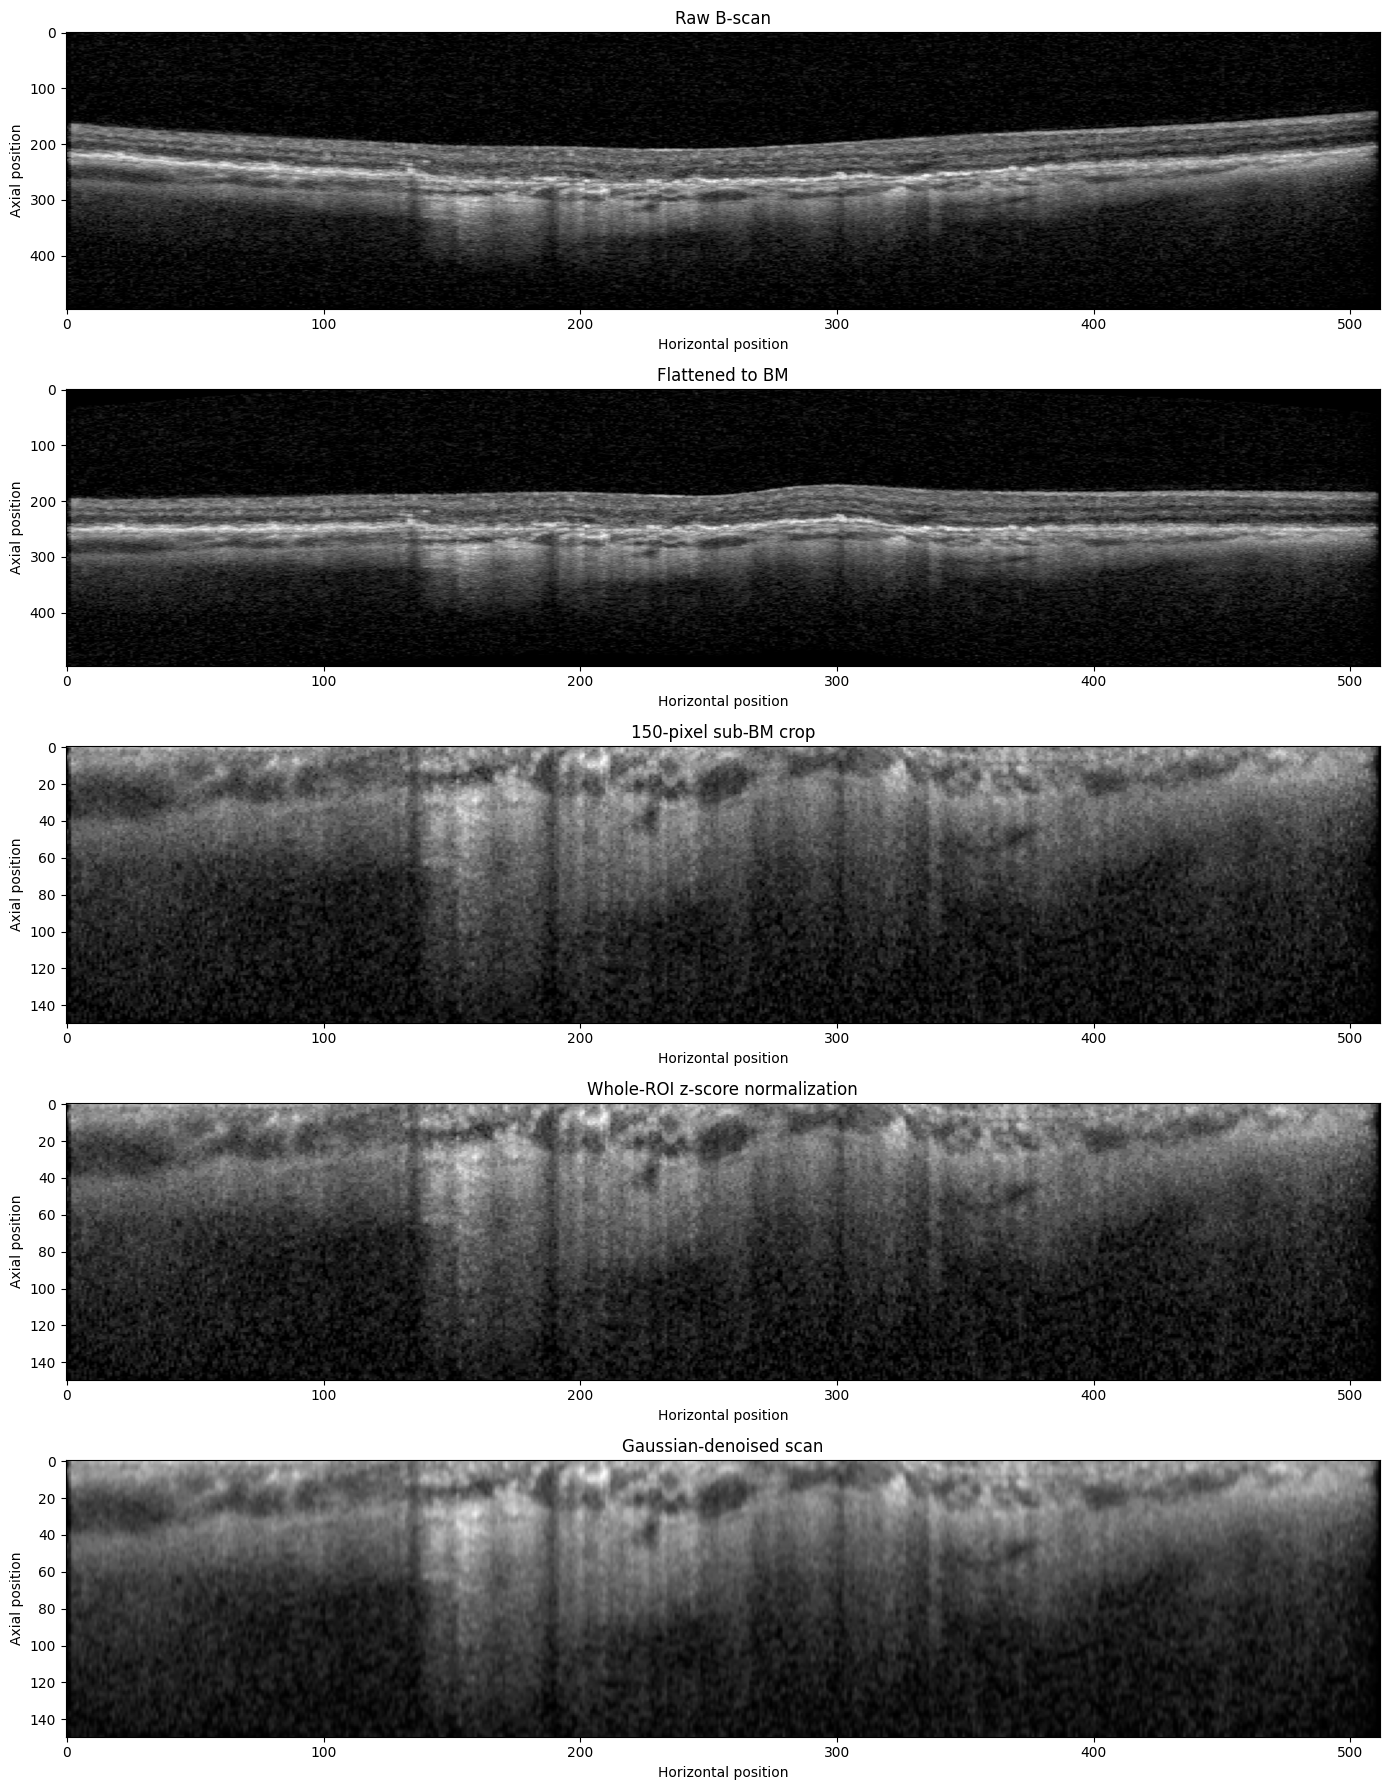

In [7]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(14, 18),
)

stages = [
    (processed.raw_bscan, "Raw B-scan"),
    (processed.flattened_bscan, "Flattened to BM"),
    (processed.sub_layer_crop, "150-pixel sub-BM crop"),
    (processed.normalized_scan, "Whole-ROI z-score normalization"),
    (processed.denoised_scan, "Gaussian-denoised scan")
    ]

for axis, (image,title) in zip( axes,stages):
    axis.imshow(
        image,
        cmap="gray",
        aspect="auto",
    )
    axis.set_title(title)
    axis.set_xlabel("Horizontal position")
    axis.set_ylabel("Axial position")
    
plt.tight_layout()
plt.show()

## Simple Gradient-Based Verticality

A vertically oriented structure produces a strong change in intensity when
moving horizontally across it, while changing less when moving along its depth.

The simple verticality score is

$$
V(z,x)
=
\frac{
|I_x(z,x)|
}{
|I_x(z,x)|+|I_z(z,x)|+\varepsilon
},
$$

where:

- $I_x$ is the horizontal image gradient;
- $I_z$ is the depth-wise image gradient;
- $\varepsilon$ prevents division by zero.

Values near one indicate horizontal-gradient dominance and therefore stronger
evidence of vertical structure. Values near zero indicate depth-wise-gradient
dominance.

In [8]:
STRUCTURAL_CONFIG = {
    "simple_verticality": {
        "smoothing_sigma": 1.0,
    },

    "structural_mask": {
        "verticality_threshold": 0.60,

        # Disabled for the first raw inspection. (None)
        "minimum_gradient_magnitude": None,

        # Disabled until the uncleaned mask is evaluated. (0)
        "minimum_component_size": 0,
    },

    "column_statistics": {
        "upper_quantile": 0.90,
        "minimum_valid_pixels": 5,
    },
}

In [9]:
simple_verticality_map, simple_verticality_diagnostics = compute_simple_verticality_map(
    image=processed.denoised_scan,
    **STRUCTURAL_CONFIG["simple_verticality"],
)

print("Verticality map shape:",simple_verticality_map.shape)
print("Verticality range:",
    float(simple_verticality_map.min()),
    "to",
    float(simple_verticality_map.max()),
)
print("Mean verticality:",float( simple_verticality_map.mean()),)

Verticality map shape: (150, 512)
Verticality range: 1.7375044990330935e-05 to 0.9999896883964539
Mean verticality: 0.5394527912139893


In [10]:
gradient_magnitude = np.hypot(
    simple_verticality_diagnostics["gradient_x"],
    simple_verticality_diagnostics["gradient_z"],
).astype(np.float32)

print("Gradient magnitude range:",
    float(gradient_magnitude.min()),
    "to",
    float(gradient_magnitude.max()),
)

Gradient magnitude range: 0.00040440840530209243 to 0.7832896113395691


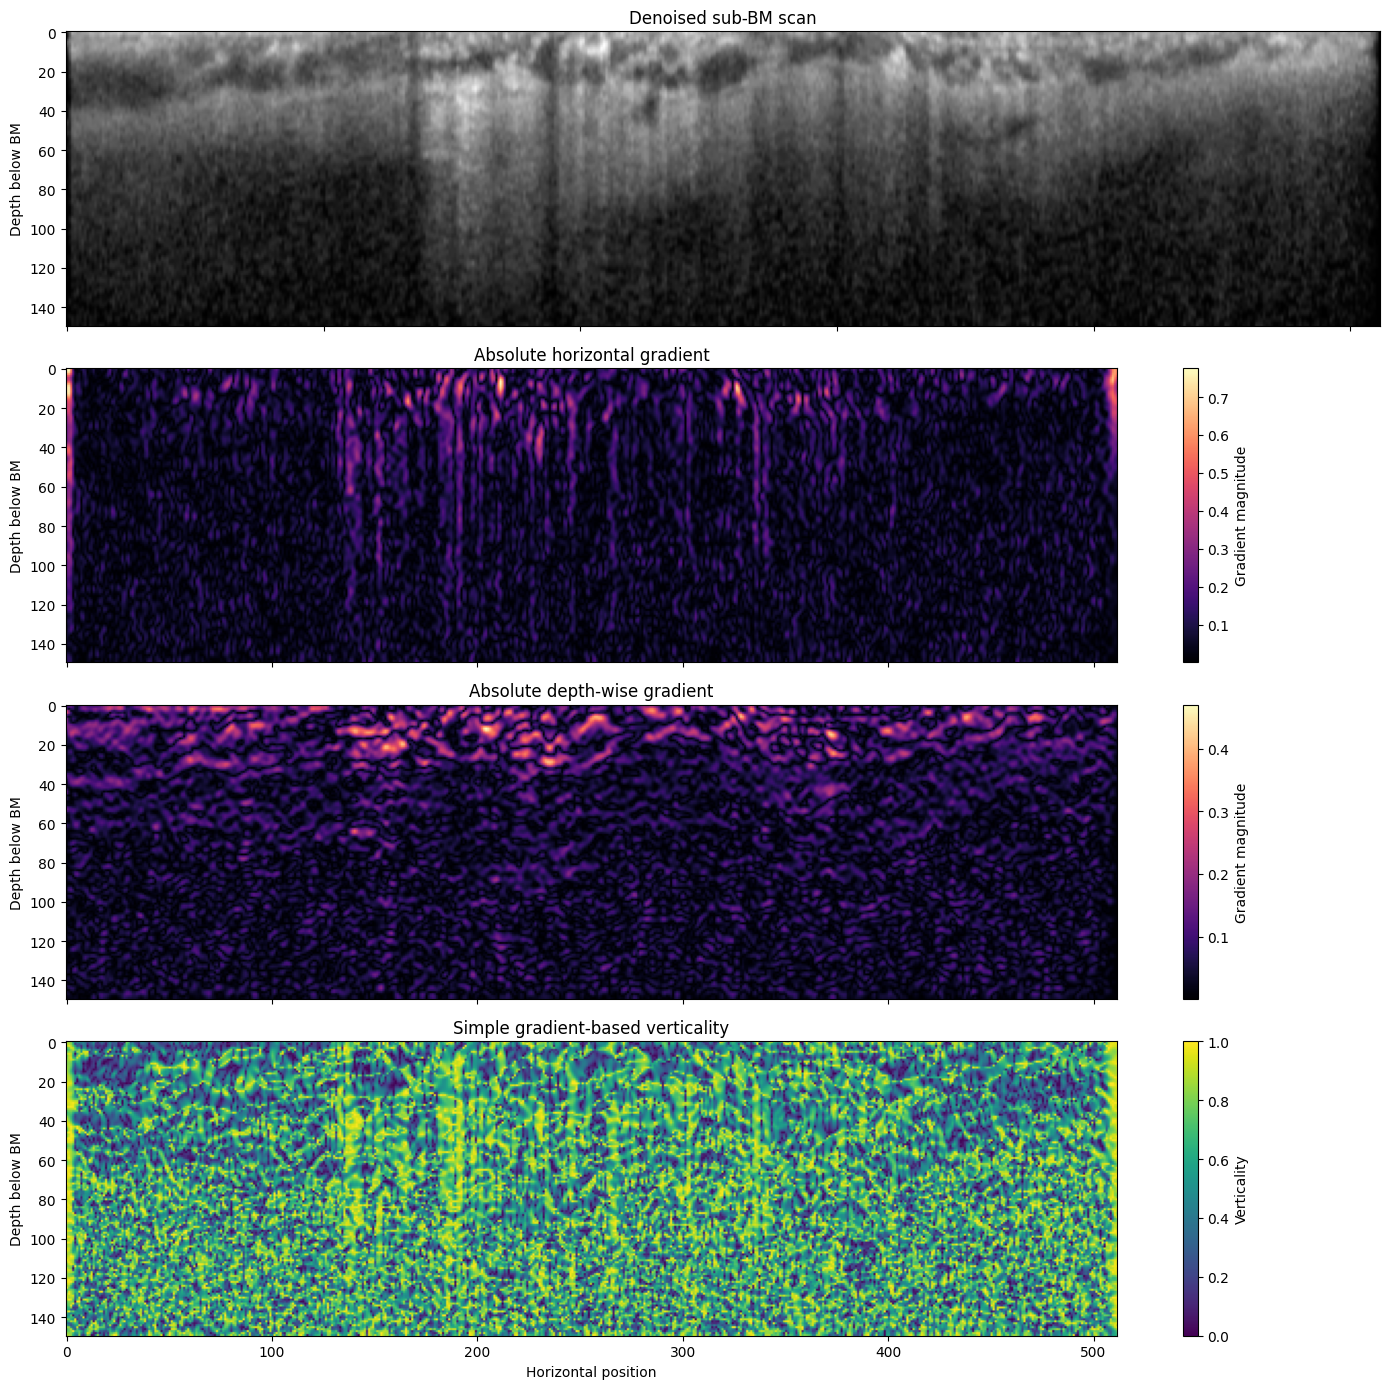

In [11]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(14, 14),
    sharex=True,
)

axes[0].imshow(
    processed.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title("Denoised sub-BM scan")
axes[0].set_ylabel("Depth below BM")

gradient_x_image = axes[1].imshow(
    np.abs(simple_verticality_diagnostics["gradient_x"]),
    cmap="magma",
    aspect="auto",
)

axes[1].set_title("Absolute horizontal gradient")
axes[1].set_ylabel("Depth below BM")

fig.colorbar(
    gradient_x_image,
    ax=axes[1],
    label="Gradient magnitude",
)

gradient_z_image = axes[2].imshow(
    np.abs(simple_verticality_diagnostics["gradient_z"]),
    cmap="magma",
    aspect="auto",
)

axes[2].set_title("Absolute depth-wise gradient")

axes[2].set_ylabel("Depth below BM")

fig.colorbar(
    gradient_z_image,
    ax=axes[2],
    label="Gradient magnitude",
)

verticality_image = axes[3].imshow(
    simple_verticality_map,
    cmap="viridis",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

axes[3].set_title("Simple gradient-based verticality")
axes[3].set_xlabel("Horizontal position")
axes[3].set_ylabel("Depth below BM")

fig.colorbar(
    verticality_image,
    ax=axes[3],
    label="Verticality",
)

plt.tight_layout()
plt.show()

## Structural-Pixel Exclusion Mask

Pixels exceeding a selected verticality threshold are marked as structurally
organized:

$$
M_{\mathrm{structure}}(z,x)
=
\mathbf{1}
\left[
V(z,x)\geq \tau_V
\right].
$$

These pixels are not immediately classified as barcoding. Instead, they are
temporarily excluded so that the remaining pixel intensities can provide an
estimate of the non-structural choroidal background.

The initial threshold is exploratory:

$$
\tau_V=0.60.
$$

In [12]:
(
    structural_mask,
    structural_mask_metadata,
) = create_structural_mask(
    verticality_map=(
        simple_verticality_map
    ),
    **STRUCTURAL_CONFIG[
        "structural_mask"
    ],
)

print("Structural-pixel fraction:",structural_mask_metadata["structural_pixel_fraction"],)
print("Structural-pixel count:",structural_mask_metadata["structural_pixel_count"],)

Structural-pixel fraction: 0.44201822916666667
Structural-pixel count: 33947


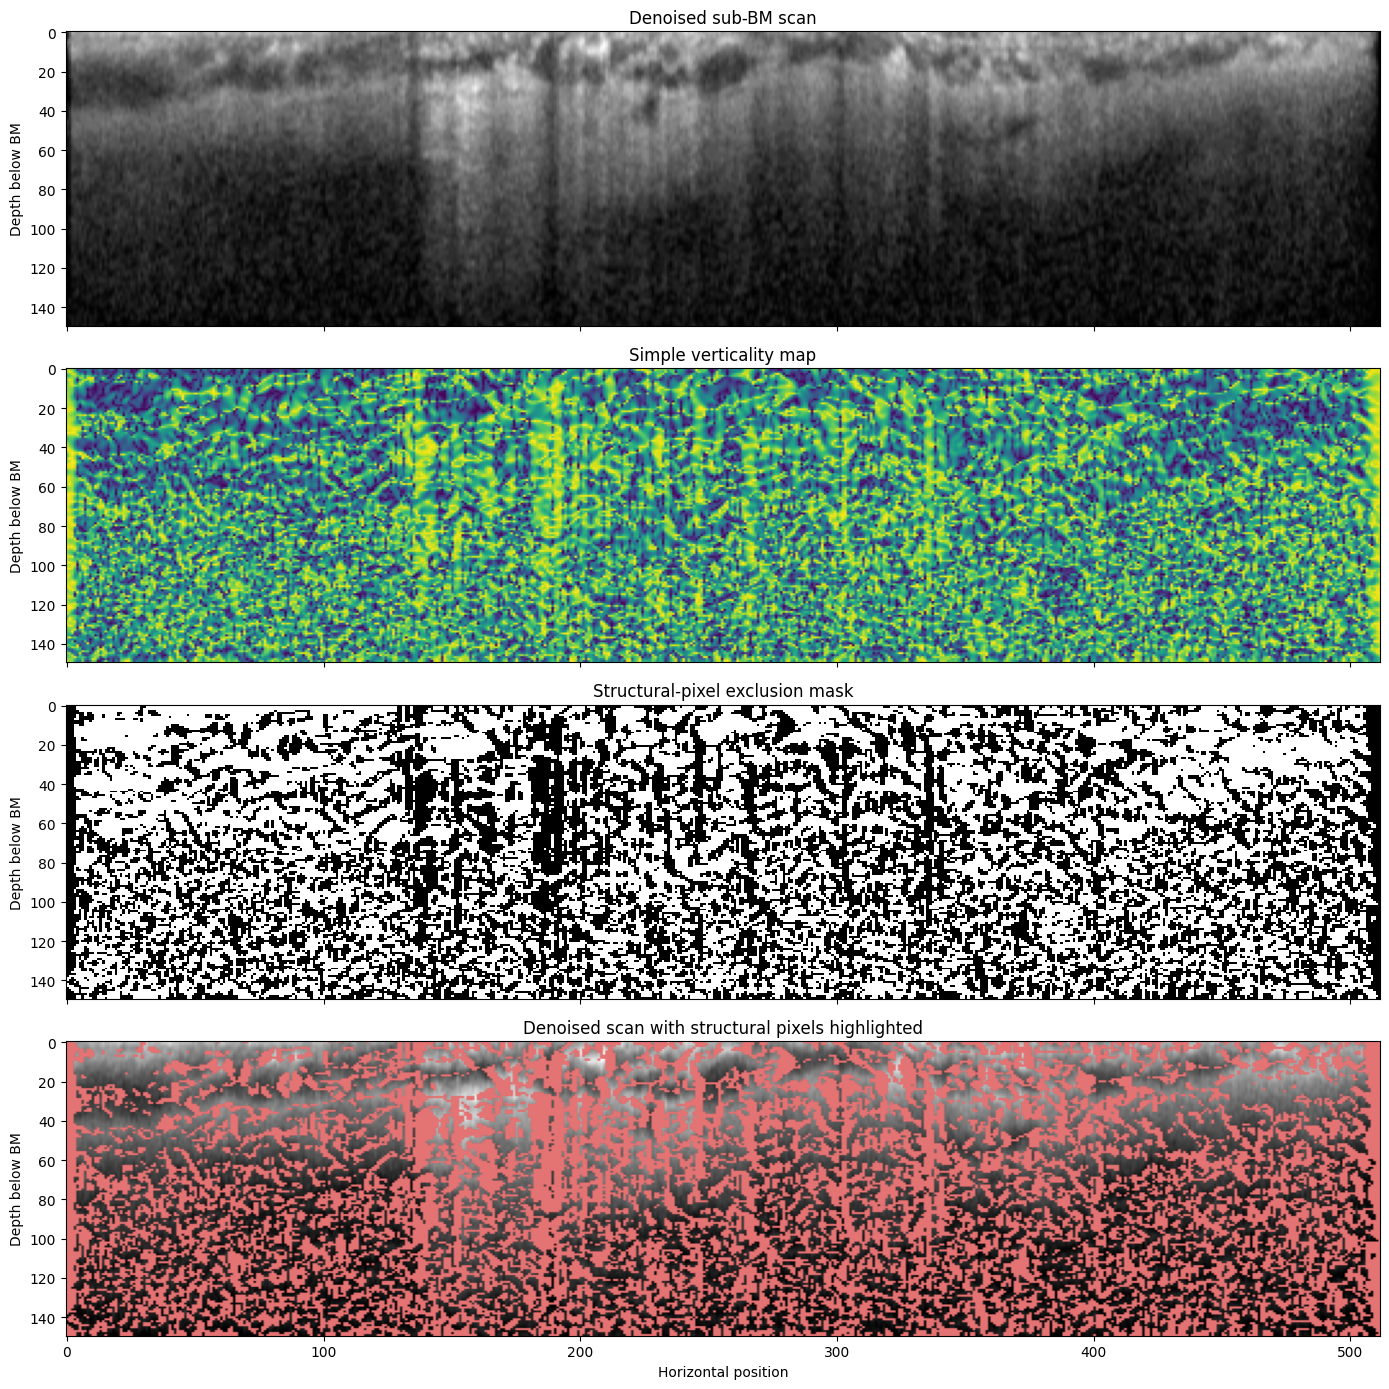

In [13]:
structurally_excluded_scan = (
    processed.denoised_scan.copy()
)

structurally_excluded_scan[
    structural_mask
] = np.nan

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(14, 14),
    sharex=True,
)

axes[0].imshow(
    processed.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title(
    "Denoised sub-BM scan"
)

axes[0].set_ylabel(
    "Depth below BM"
)

axes[1].imshow(
    simple_verticality_map,
    cmap="viridis",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title(
    "Simple verticality map"
)

axes[1].set_ylabel(
    "Depth below BM"
)

axes[2].imshow(
    structural_mask,
    cmap="binary",
    aspect="auto",
    interpolation="nearest",
)

axes[2].set_title(
    "Structural-pixel exclusion mask"
)

axes[2].set_ylabel(
    "Depth below BM"
)

masked_colormap = plt.get_cmap(
    "gray"
).copy()

masked_colormap.set_bad(
    color="tab:red",
    alpha=0.65,
)

axes[3].imshow(
    structurally_excluded_scan,
    cmap=masked_colormap,
    aspect="auto",
)

axes[3].set_title(
    "Denoised scan with structural pixels highlighted"
)

axes[3].set_xlabel(
    "Horizontal position"
)

axes[3].set_ylabel(
    "Depth below BM"
)

plt.tight_layout()
plt.show()

## Intensity Distribution After Structural Exclusion

The non-structural choroid is defined as the set of pixels not included in the
structural mask:

$$
\mathcal{C}
=
\left\{
I(z,x):
M_{\mathrm{structure}}(z,x)=0
\right\}.
$$

The full ROI distribution is compared with the structurally cleaned
distribution.

The following summaries are inspected:

- mean;
- median;
- 90th percentile;
- interquartile range.

This determines whether removing strongly oriented pixels changes the estimated
background-intensity distribution.

In [14]:
all_roi_intensities = (
    processed.denoised_scan[
        np.isfinite(
            processed.denoised_scan
        )
    ]
)

clean_choroid_intensities = (
    processed.denoised_scan[
        ~structural_mask
    ]
)

print(
    "All ROI pixels:",
    all_roi_intensities.size,
)

print(
    "Retained clean-choroid pixels:",
    clean_choroid_intensities.size,
)

print(
    "Retained fraction:",
    clean_choroid_intensities.size
    / all_roi_intensities.size,
)

All ROI pixels: 76800
Retained clean-choroid pixels: 42853
Retained fraction: 0.5579817708333333


In [15]:
def summarize_intensity_distribution(
    values: np.ndarray,
) -> dict[str, float]:
    """
    Return robust intensity summaries.
    """
    values = np.asarray(
        values,
        dtype=np.float32,
    )

    values = values[
        np.isfinite(values)
    ]

    return {
        "mean": float(
            np.mean(values)
        ),
        "median": float(
            np.median(values)
        ),
        "q25": float(
            np.quantile(
                values,
                0.25,
            )
        ),
        "q75": float(
            np.quantile(
                values,
                0.75,
            )
        ),
        "q90": float(
            np.quantile(
                values,
                0.90,
            )
        ),
        "q95": float(
            np.quantile(
                values,
                0.95,
            )
        ),
        "standard_deviation": float(
            np.std(values)
        ),
    }


all_roi_summary = (
    summarize_intensity_distribution(
        all_roi_intensities
    )
)

clean_choroid_summary = (
    summarize_intensity_distribution(
        clean_choroid_intensities
    )
)

print("All ROI:")
for name, value in (
    all_roi_summary.items()
):
    print(
        f"  {name}: {value:.4f}"
    )

print("\nStructurally cleaned choroid:")
for name, value in (
    clean_choroid_summary.items()
):
    print(
        f"  {name}: {value:.4f}"
    )

All ROI:
  mean: 0.0000
  median: -0.2494
  q25: -0.8183
  q75: 0.7456
  q90: 1.4141
  q95: 1.7978
  standard_deviation: 0.9698

Structurally cleaned choroid:
  mean: 0.0618
  median: -0.1396
  q25: -0.7900
  q75: 0.8124
  q90: 1.4780
  q95: 1.8288
  standard_deviation: 0.9789


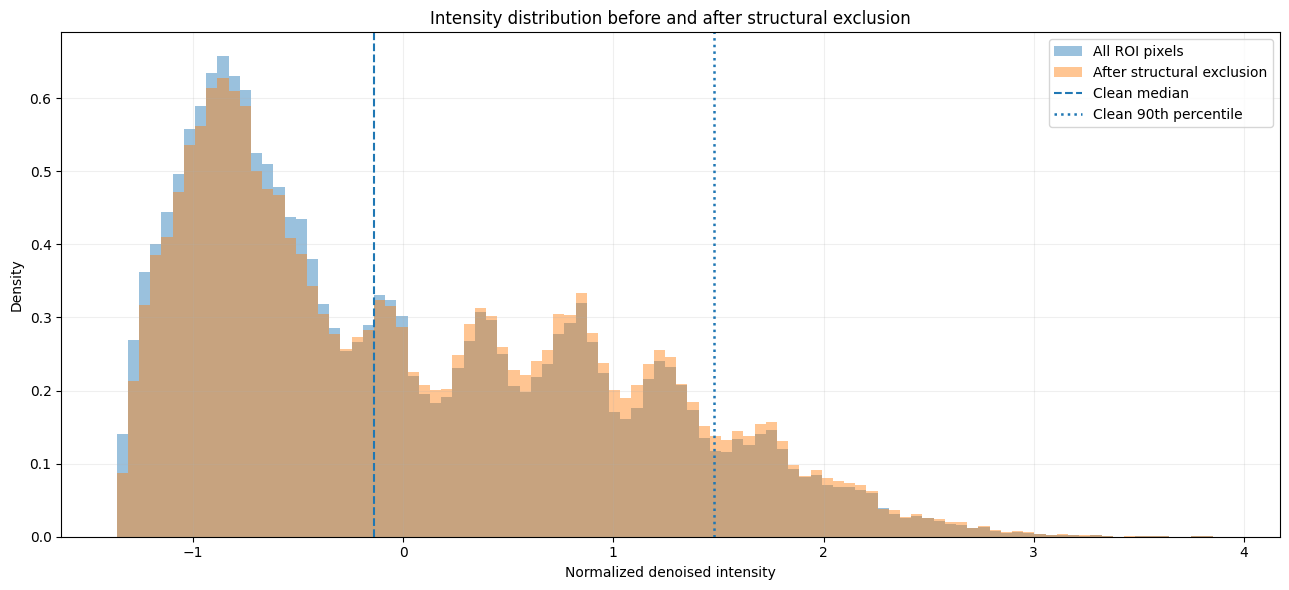

In [16]:
combined_minimum = float(
    min(
        all_roi_intensities.min(),
        clean_choroid_intensities.min(),
    )
)

combined_maximum = float(
    max(
        all_roi_intensities.max(),
        clean_choroid_intensities.max(),
    )
)

histogram_bins = np.linspace(
    combined_minimum,
    combined_maximum,
    100,
)

plt.figure(
    figsize=(13, 6)
)

plt.hist(
    all_roi_intensities,
    bins=histogram_bins,
    density=True,
    alpha=0.45,
    label="All ROI pixels",
)

plt.hist(
    clean_choroid_intensities,
    bins=histogram_bins,
    density=True,
    alpha=0.45,
    label=(
        "After structural exclusion"
    ),
)

plt.axvline(
    clean_choroid_summary[
        "median"
    ],
    linestyle="--",
    linewidth=1.5,
    label="Clean median",
)

plt.axvline(
    clean_choroid_summary[
        "q90"
    ],
    linestyle=":",
    linewidth=1.8,
    label="Clean 90th percentile",
)

plt.title(
    "Intensity distribution before and after structural exclusion"
)

plt.xlabel(
    "Normalized denoised intensity"
)

plt.ylabel(
    "Density"
)

plt.legend()
plt.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()

## Column-Level Intensity Summaries

For each horizontal position $x$, only non-structural pixels are retained.

The following statistics are calculated through depth:

$$
\mu(x)
=
\operatorname{mean}
\left(
\mathcal{C}_x
\right),
$$

$$
m(x)
=
\operatorname{median}
\left(
\mathcal{C}_x
\right),
$$

$$
q_{90}(x)
=
Q_{0.90}
\left(
\mathcal{C}_x
\right),
$$

where $\mathcal{C}_x$ is the set of retained intensities in column $x$.

The mean reflects broad intensity elevation, the median describes the typical
column intensity, and the 90th percentile reflects the upper-intensity portion
of the column.

In [17]:
(
    column_statistics,
    column_statistics_metadata,
) = compute_column_intensity_statistics(
    image=processed.denoised_scan,
    exclusion_mask=structural_mask,
    **STRUCTURAL_CONFIG[
        "column_statistics"
    ],
)

print(
    "Columns with sufficient data:",
    column_statistics_metadata[
        "columns_with_sufficient_data"
    ],
)

print(
    "Columns with insufficient data:",
    column_statistics_metadata[
        "columns_with_insufficient_data"
    ],
)

Columns with sufficient data: 508
Columns with insufficient data: 4


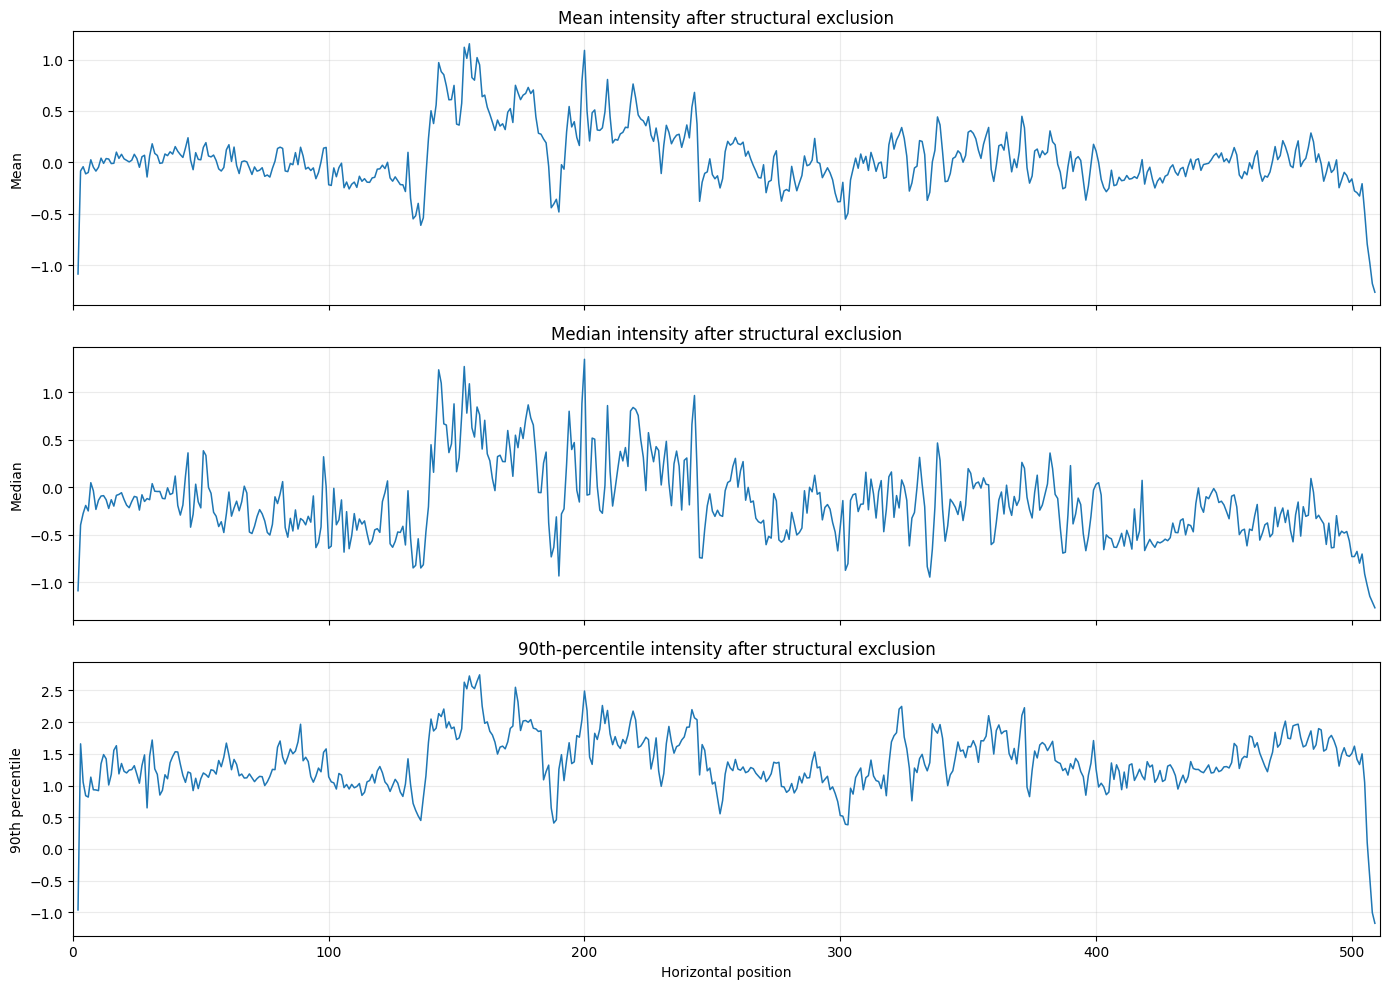

In [18]:
horizontal_positions = np.arange(
    processed.denoised_scan.shape[1]
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 10),
    sharex=True,
)

axes[0].plot(
    horizontal_positions,
    column_statistics[
        "mean"
    ],
    linewidth=1.1,
)

axes[0].set_title(
    "Mean intensity after structural exclusion"
)

axes[0].set_ylabel(
    "Mean"
)

axes[1].plot(
    horizontal_positions,
    column_statistics[
        "median"
    ],
    linewidth=1.1,
)

axes[1].set_title(
    "Median intensity after structural exclusion"
)

axes[1].set_ylabel(
    "Median"
)

axes[2].plot(
    horizontal_positions,
    column_statistics[
        "upper_quantile"
    ],
    linewidth=1.1,
)

axes[2].set_title(
    "90th-percentile intensity after structural exclusion"
)

axes[2].set_xlabel(
    "Horizontal position"
)

axes[2].set_ylabel(
    "90th percentile"
)

for axis in axes:
    axis.grid(
        alpha=0.25
    )

    axis.set_xlim(
        0,
        processed.denoised_scan.shape[1]
        - 1,
    )

plt.tight_layout()
plt.show()

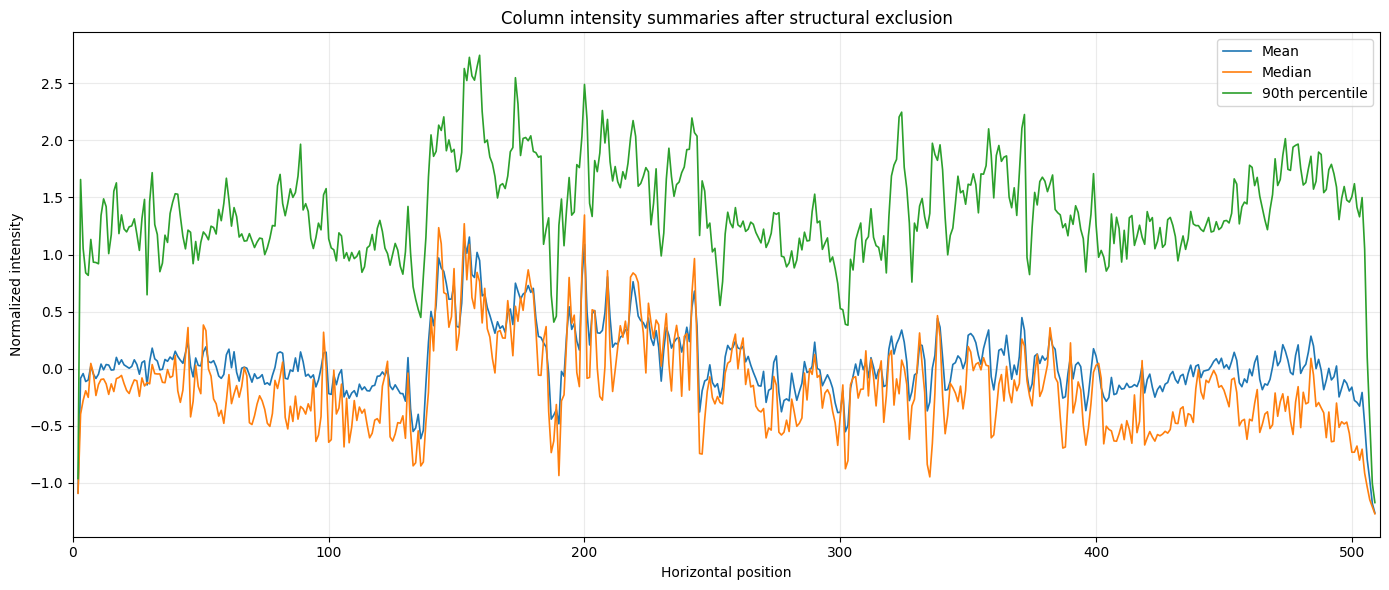

In [19]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    horizontal_positions,
    column_statistics[
        "mean"
    ],
    label="Mean",
    linewidth=1.2,
)

plt.plot(
    horizontal_positions,
    column_statistics[
        "median"
    ],
    label="Median",
    linewidth=1.2,
)

plt.plot(
    horizontal_positions,
    column_statistics[
        "upper_quantile"
    ],
    label="90th percentile",
    linewidth=1.2,
)

plt.title(
    "Column intensity summaries after structural exclusion"
)

plt.xlabel(
    "Horizontal position"
)

plt.ylabel(
    "Normalized intensity"
)

plt.xlim(
    0,
    processed.denoised_scan.shape[1]
    - 1,
)

plt.legend()
plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

Our simple verticality ratio is labeling too many pixels since we are looking at relative direction of gradients. The two distributions nearly overlap so the current mask is not removing s distinct structural population. We will add a gradient-magnitude gate, which will require a pixel to have both a vertically compatible gradient direction and a sufficiently strong boundary. 
$$
M_{\mathrm{structure}}(z,x)
=
\mathbf{1}
\left[
V(z,x)\geq\tau_V
\right]
\mathbf{1}
\left[
G(z,x)\geq\tau_G
\right],
$$
where
$$
G(z,x)
=
\sqrt{
I_x(z,x)^2+I_z(z,x)^2
}.
$$

In [20]:
# look at grad-mag dist'n
gradient_quantiles = {
    quantile: float(
        np.quantile(
            gradient_magnitude,
            quantile,
        )
    )
    for quantile in (
        0.50,
        0.60,
        0.70,
        0.75,
        0.80,
        0.85,
        0.90,
        0.95,
    )
}

for quantile, value in gradient_quantiles.items():
    print(
        f"Gradient Q{int(100 * quantile):02d}: "
        f"{value:.6f}"
    )

Gradient Q50: 0.077928
Gradient Q60: 0.091220
Gradient Q70: 0.107627
Gradient Q75: 0.117376
Gradient Q80: 0.130093
Gradient Q85: 0.147728
Gradient Q90: 0.175664
Gradient Q95: 0.228503


In [21]:
STRUCTURAL_MASK_TESTS = {
    "verticality_only": {
        "verticality_threshold": 0.60,
        "minimum_gradient_magnitude": None,
    },
    "gradient_q70": {
        "verticality_threshold": 0.60,
        "minimum_gradient_magnitude": (
            gradient_quantiles[0.70]
        ),
    },
    "gradient_q80": {
        "verticality_threshold": 0.60,
        "minimum_gradient_magnitude": (
            gradient_quantiles[0.80]
        ),
    },
    "gradient_q90": {
        "verticality_threshold": 0.60,
        "minimum_gradient_magnitude": (
            gradient_quantiles[0.90]
        ),
    },
}

In [22]:
structural_mask_tests = {}

for label, mask_config in (
    STRUCTURAL_MASK_TESTS.items()
):
    test_mask, test_metadata = (
        create_structural_mask(
            verticality_map=(
                simple_verticality_map
            ),
            gradient_magnitude=(
                gradient_magnitude
            ),
            verticality_threshold=(
                mask_config[
                    "verticality_threshold"
                ]
            ),
            minimum_gradient_magnitude=(
                mask_config[
                    "minimum_gradient_magnitude"
                ]
            ),
            minimum_component_size=0,
        )
    )

    structural_mask_tests[
        label
    ] = {
        "mask": test_mask,
        "metadata": test_metadata,
    }

    print(
        f"{label}: "
        f"{test_metadata['structural_pixel_fraction']:.3f} "
        "of pixels excluded"
    )

verticality_only: 0.442 of pixels excluded
gradient_q70: 0.151 of pixels excluded
gradient_q80: 0.103 of pixels excluded
gradient_q90: 0.053 of pixels excluded


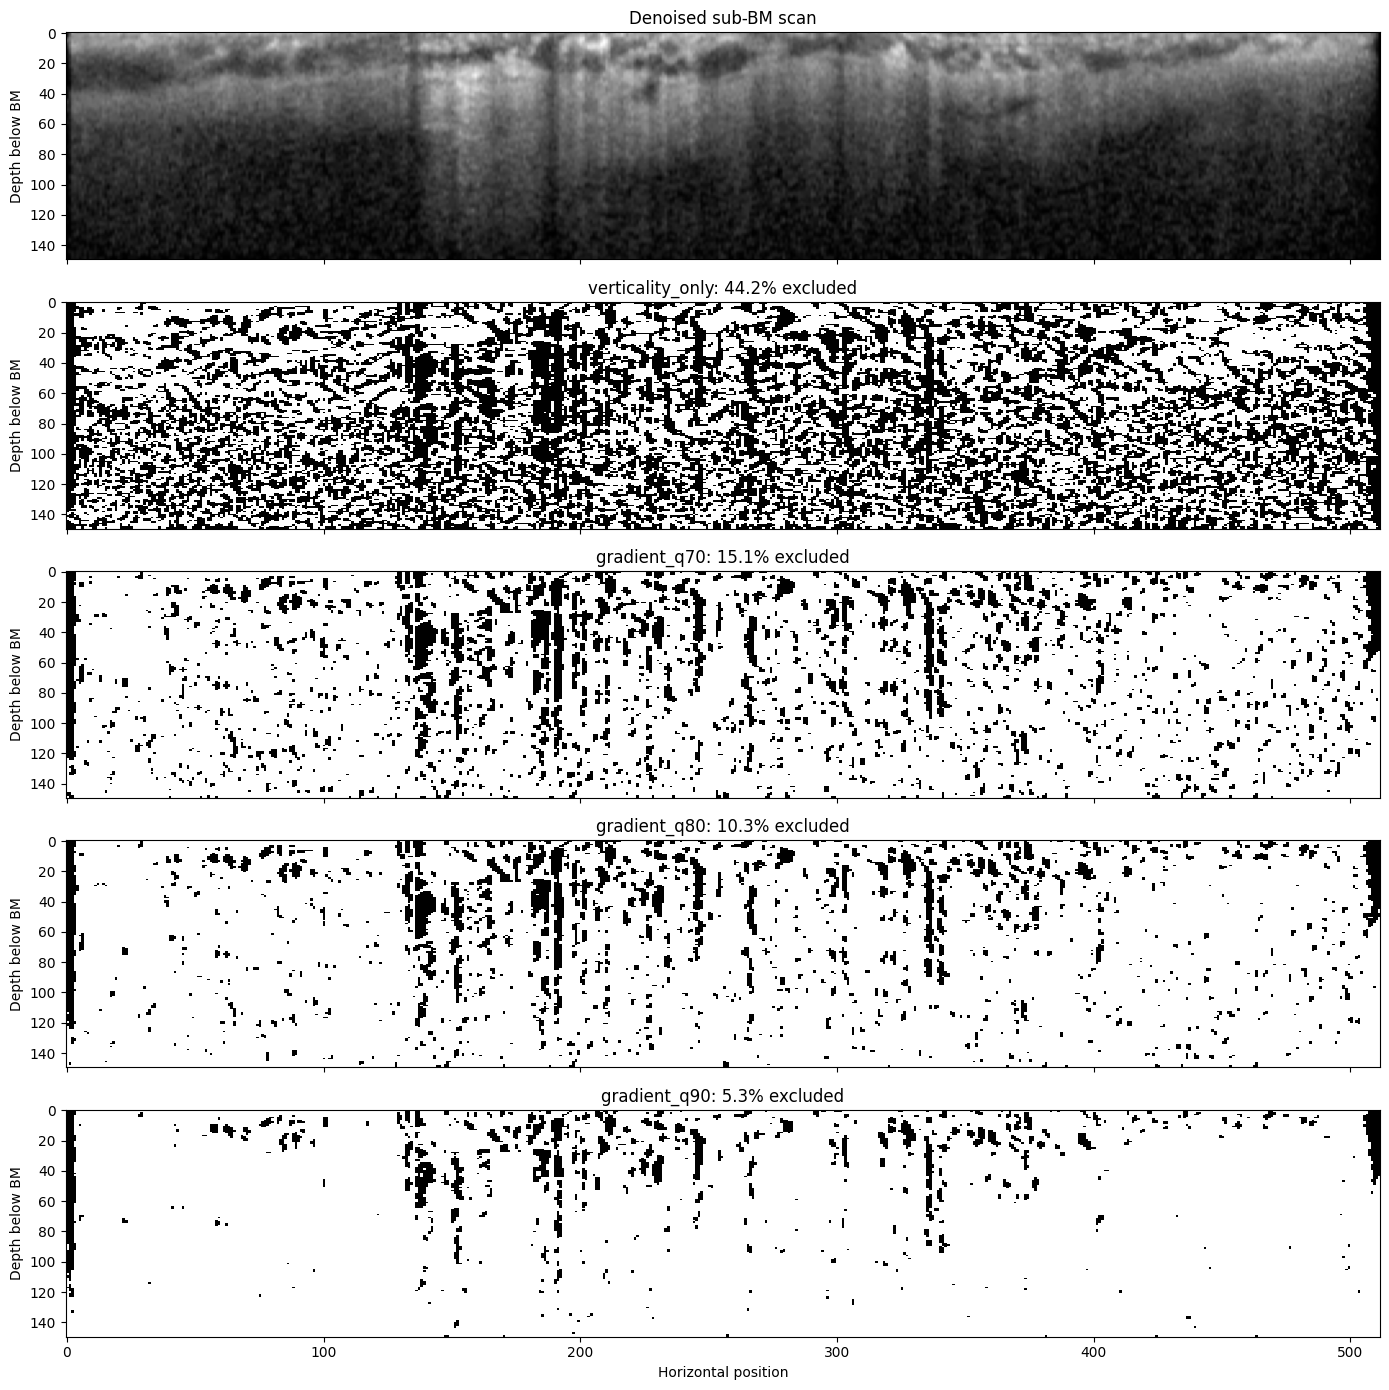

In [23]:
fig, axes = plt.subplots(
    nrows=len(
        structural_mask_tests
    ) + 1,
    ncols=1,
    figsize=(14, 14),
    sharex=True,
)

axes[0].imshow(
    processed.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title(
    "Denoised sub-BM scan"
)

axes[0].set_ylabel(
    "Depth below BM"
)

for axis, (
    label,
    test_result,
) in zip(
    axes[1:],
    structural_mask_tests.items(),
):
    axis.imshow(
        test_result["mask"],
        cmap="binary",
        aspect="auto",
        interpolation="nearest",
    )

    excluded_fraction = (
        test_result[
            "metadata"
        ][
            "structural_pixel_fraction"
        ]
    )

    axis.set_title(
        f"{label}: "
        f"{excluded_fraction:.1%} excluded"
    )

    axis.set_ylabel(
        "Depth below BM"
    )

axes[-1].set_xlabel(
    "Horizontal position"
)

plt.tight_layout()
plt.show()

In [25]:
SELECTED_STRUCTURAL_MASK = "gradient_q80"

structural_mask = structural_mask_tests[
    SELECTED_STRUCTURAL_MASK
]["mask"]

structural_mask_metadata = structural_mask_tests[
    SELECTED_STRUCTURAL_MASK
]["metadata"]

print(
    "Selected structural mask:",
    SELECTED_STRUCTURAL_MASK,
)

print(
    "Excluded pixel fraction:",
    structural_mask_metadata[
        "structural_pixel_fraction"
    ],
)

Selected structural mask: gradient_q80
Excluded pixel fraction: 0.1028515625


In [26]:
all_roi_intensities = processed.denoised_scan[
    np.isfinite(
        processed.denoised_scan
    )
]

clean_choroid_intensities = processed.denoised_scan[
    ~structural_mask
]

all_roi_summary = summarize_intensity_distribution(
    all_roi_intensities
)

clean_choroid_summary = summarize_intensity_distribution(
    clean_choroid_intensities
)

print("All ROI:")
for name, value in all_roi_summary.items():
    print(
        f"  {name}: {value:.4f}"
    )

print("\nGradient-gated clean choroid:")
for name, value in clean_choroid_summary.items():
    print(
        f"  {name}: {value:.4f}"
    )

All ROI:
  mean: 0.0000
  median: -0.2494
  q25: -0.8183
  q75: 0.7456
  q90: 1.4141
  q95: 1.7978
  standard_deviation: 0.9698

Gradient-gated clean choroid:
  mean: -0.0623
  median: -0.3455
  q25: -0.8409
  q75: 0.6452
  q90: 1.3299
  q95: 1.7360
  standard_deviation: 0.9442


In [27]:
(
    column_statistics,
    column_statistics_metadata,
) = compute_column_intensity_statistics(
    image=processed.denoised_scan,
    exclusion_mask=structural_mask,
    **STRUCTURAL_CONFIG[
        "column_statistics"
    ],
)

print(
    "Columns with sufficient data:",
    column_statistics_metadata[
        "columns_with_sufficient_data"
    ],
)

print(
    "Columns with insufficient data:",
    column_statistics_metadata[
        "columns_with_insufficient_data"
    ],
)

print(
    "Median retained fraction:",
    float(
        np.nanmedian(
            column_statistics[
                "valid_pixel_fraction"
            ]
        )
    ),
)

Columns with sufficient data: 512
Columns with insufficient data: 0
Median retained fraction: 0.9333333373069763


In [28]:
# mask out unstable columns
MINIMUM_RETAINED_FRACTION = 0.75

stable_column_mask = (
    column_statistics[
        "valid_pixel_fraction"
    ]
    >= MINIMUM_RETAINED_FRACTION
)


In [29]:
stable_column_statistics = {}

for statistic_name in (
    "mean",
    "median",
    "upper_quantile",
    "standard_deviation",
):
    values = column_statistics[
        statistic_name
    ].copy()

    values[
        ~stable_column_mask
    ] = np.nan

    stable_column_statistics[
        statistic_name
    ] = values

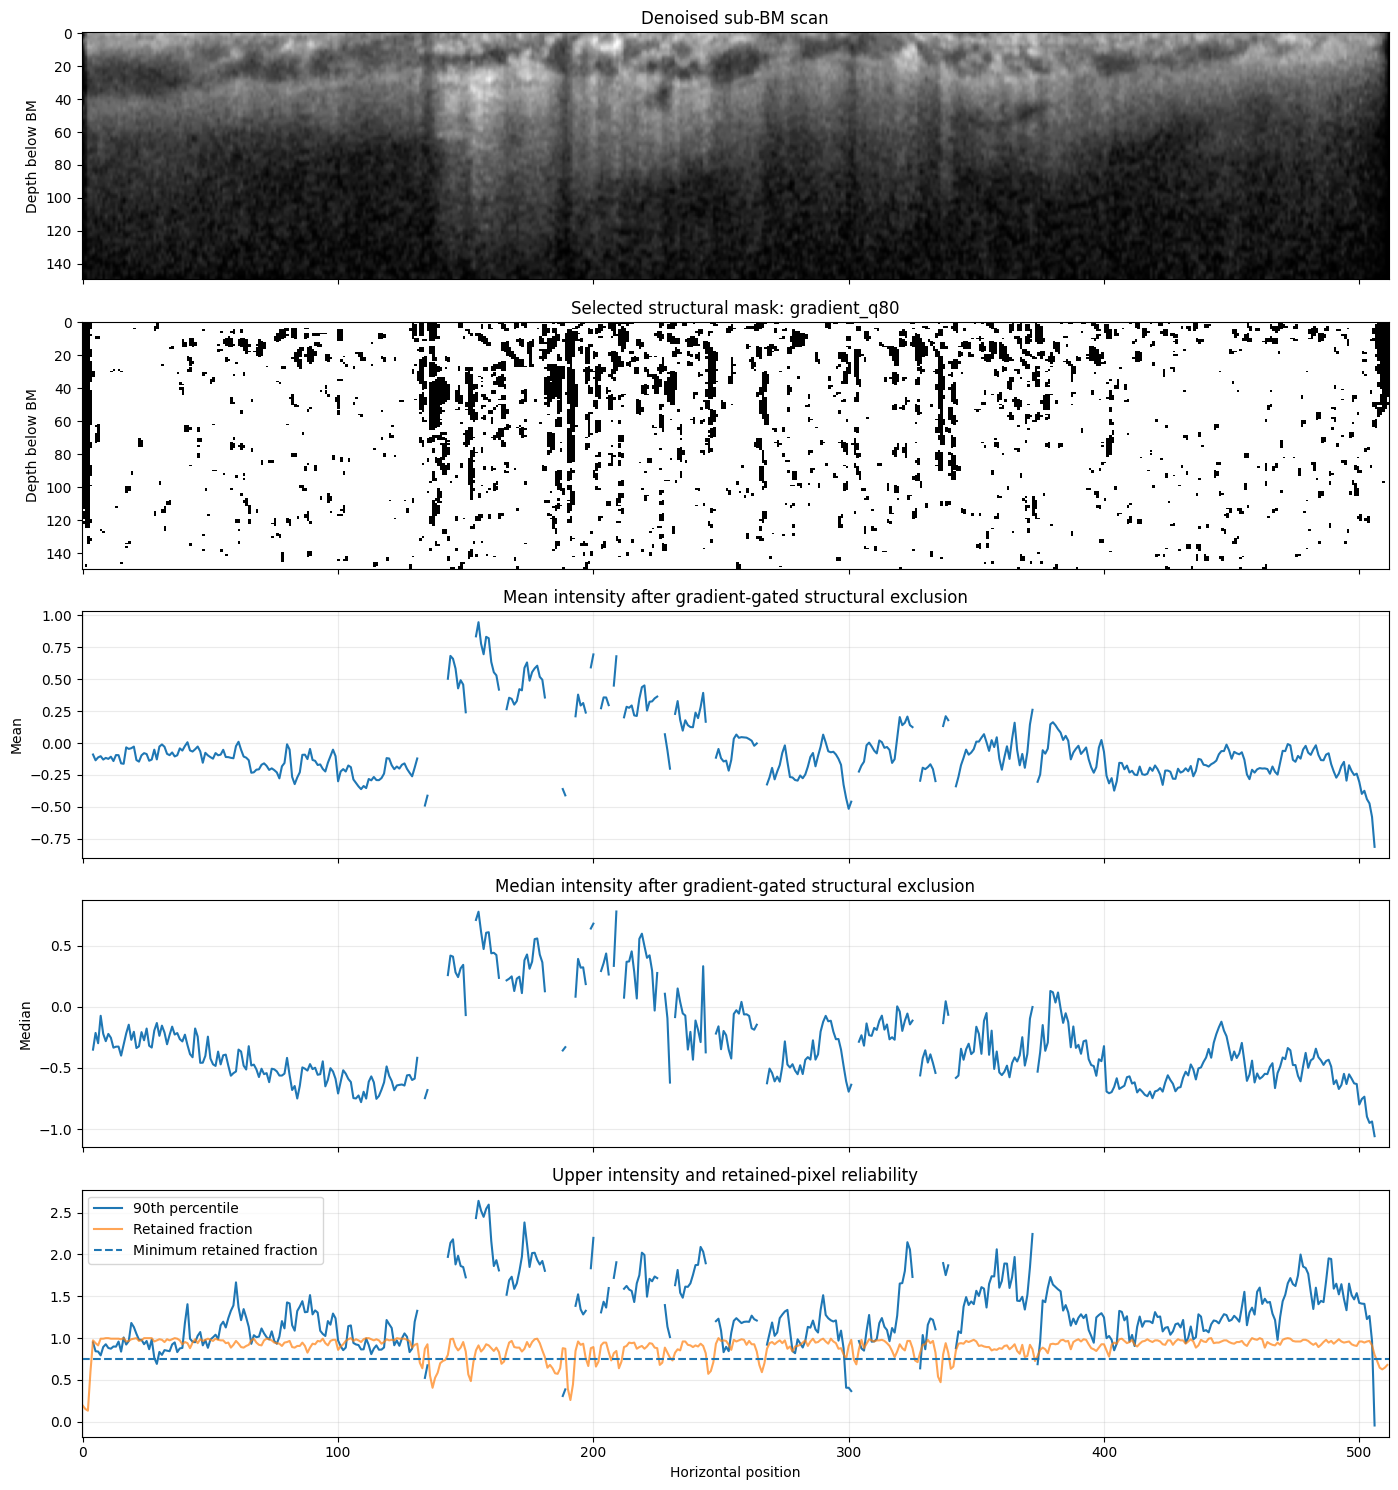

In [30]:
horizontal_positions = np.arange(
    processed.denoised_scan.shape[1]
)

fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 15),
    sharex=True,
)

axes[0].imshow(
    processed.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title(
    "Denoised sub-BM scan"
)

axes[0].set_ylabel(
    "Depth below BM"
)

axes[1].imshow(
    structural_mask,
    cmap="binary",
    aspect="auto",
    interpolation="nearest",
)

axes[1].set_title(
    f"Selected structural mask: "
    f"{SELECTED_STRUCTURAL_MASK}"
)

axes[1].set_ylabel(
    "Depth below BM"
)

axes[2].plot(
    horizontal_positions,
    stable_column_statistics[
        "mean"
    ],
)

axes[2].set_title(
    "Mean intensity after gradient-gated structural exclusion"
)

axes[2].set_ylabel(
    "Mean"
)

axes[3].plot(
    horizontal_positions,
    stable_column_statistics[
        "median"
    ],
)

axes[3].set_title(
    "Median intensity after gradient-gated structural exclusion"
)

axes[3].set_ylabel(
    "Median"
)

axes[4].plot(
    horizontal_positions,
    stable_column_statistics[
        "upper_quantile"
    ],
    label="90th percentile",
)

axes[4].plot(
    horizontal_positions,
    column_statistics[
        "valid_pixel_fraction"
    ],
    label="Retained fraction",
    alpha=0.7,
)

axes[4].axhline(
    MINIMUM_RETAINED_FRACTION,
    linestyle="--",
    label="Minimum retained fraction",
)

axes[4].set_title(
    "Upper intensity and retained-pixel reliability"
)

axes[4].set_xlabel(
    "Horizontal position"
)

axes[4].legend()

for axis in axes[2:]:
    axis.grid(
        alpha=0.25
    )

plt.tight_layout()
plt.show()